In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import gymnasium as gym
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from Network import *
from inputFuc import *
from plotting import *
from utilsRL import *
from IPython.display import display, clear_output
import time
import imageio
import pickle

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)

general_config['save_path'] = "../saved_models/Cartpole/"

#### With P learning ###
dt = general_config["dt"]
action_step = 0.02

# init both teacher and student net
batch = train_config["batch_size"]
general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

# Create the CartPole environment
env = CartPoleCustomize(obs='velocity')

n_actions = env.env.action_space.n.item()
# Get the number of state observations
obs, info = env.reset()
n_observations = obs.shape[-1]

actor_config = dict(default_model_config)
critic_config = dict(default_model_config)
actor_config['n_in'] = n_observations
critic_config['n_in'] = n_observations
actor_config['n_out'] = n_actions
critic_config['n_out'] = 1

cpu


# Train from scratch

In [14]:
def episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()
    device = actor.device

    terminated, truncated = False, False
    total_reward=0
    lamd = 0.9
    gamma = 0.99 # are they different?
    rwd_scale = 0.2

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)
    observations = observations.to(device)
    delta_rec = 0

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            if truncated:
                break
            reward *= rwd_scale

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]
            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value
            delta_rec += torch.abs(delta)           
            delta = torch.clamp(delta, -0.015, 0.015).to(device)
            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions).to(device)-p)
            actor.backwardsRL(delta.item(), lamd)            
            critic.prop(1.)
            critic.backwardsRL(delta.item(), lamd)

            if t%150==0:
                torch.nn.utils.clip_grad_norm_(actor.parameters(), 0.8)
                torch.nn.utils.clip_grad_norm_(critic.parameters(), 0.8)
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)

            observation = observation_next
            total_reward+=reward
            t += 1

        torch.nn.utils.clip_grad_norm_(actor.parameters(), 0.8)
        torch.nn.utils.clip_grad_norm_(critic.parameters(), 0.8)
        optimizer_actor.step()
        optimizer_critic.step()
        optimizer_actor.zero_grad(set_to_none=False)
        optimizer_critic.zero_grad(set_to_none=False)
        soft_update(critic_target, critic, tau = 0.05)      

    return total_reward/rwd_scale, t, delta_rec/t

In [15]:
#Change schedular, add temporatue?
actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)
for p in critic_target.parameters():
    p.requires_grad = False
hard_update(critic_target, critic)
num_episode = 4000

optimizer_actor = torch.optim.Adam(
    actor.parameters(),
    lr=1e-4, 
    betas=(0.9, 0.999)
)

optimizer_critic = torch.optim.Adam(
    critic.parameters(),
    lr=1e-3, 
    betas=(0.9, 0.999)
)

In [16]:
save_dict = {'step':[], 'reward':[]}
R_avg, duration_avg, delta_avg = 10, 0, 0
best_R, best_duration = 0, 0
R_rec, delta_rec = [], []
for i in range(num_episode):
    total_reward, duration, delta = episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic)
    save_dict['step'].append(duration)
    save_dict['reward'].append(total_reward)
    if total_reward < R_avg:
        actor.beta *= 0.997
        critic.beta *= 0.997
    else:
        actor.beta += 0.001
        critic.beta += 0.001
    R_avg = 0.98*R_avg + 0.02*total_reward
    duration_avg = 0.98*duration_avg + 0.02*duration
    delta_avg = 0.98*delta_avg + 0.02*delta
    if i%100==99:
        R_rec.append(R_avg)
        saved = False
        if R_avg > best_R:
            best_R = R_avg
        print(f"Reward:{R_avg:.2f}, Steps:{duration_avg:.2f}, delta:{delta_avg.item():.3f}, beta:{actor.beta:.3f}")
    if duration_avg > 496 and R_avg > 490:
        best_R = R_avg
        print("Learning Success")
        break
best_actor_state = actor.state_dict().copy()
best_critic_state = critic.state_dict().copy()      
env.close() # Close the environment
save_dict['step'] = np.array(save_dict['step'])
save_dict['reward'] = np.array(save_dict['reward'])

Reward:13.43, Steps:15.47, delta:0.065, beta:0.913
Reward:13.65, Steps:17.99, delta:0.065, beta:0.809
Reward:47.79, Steps:58.96, delta:0.096, beta:0.784
Reward:112.27, Steps:138.93, delta:0.086, beta:0.766
Reward:154.31, Steps:191.45, delta:0.081, beta:0.724
Reward:172.94, Steps:225.08, delta:0.087, beta:0.668
Reward:198.20, Steps:258.78, delta:0.089, beta:0.621
Reward:200.04, Steps:258.09, delta:0.091, beta:0.576
Reward:245.26, Steps:306.36, delta:0.089, beta:0.552
Reward:249.94, Steps:324.05, delta:0.089, beta:0.508
Reward:281.95, Steps:355.08, delta:0.097, beta:0.488
Reward:331.84, Steps:402.19, delta:0.086, beta:0.492
Reward:382.78, Steps:445.84, delta:0.085, beta:0.493
Reward:419.57, Steps:472.53, delta:0.073, beta:0.502
Reward:457.32, Steps:489.09, delta:0.060, beta:0.540
Reward:473.33, Steps:494.17, delta:0.050, beta:0.576
Reward:466.25, Steps:495.59, delta:0.040, beta:0.575
Reward:475.45, Steps:498.55, delta:0.034, beta:0.596
Reward:451.45, Steps:498.94, delta:0.039, beta:0.530

### Saving

In [17]:
torch.save(best_actor_state, general_config['save_path']+"actor%d.ckp"%int(best_R))
torch.save(best_critic_state, general_config['save_path']+"critic%d.ckp"%int(best_R))

In [18]:
save_path = "../Figures/CartpoleTrainRecord.pkl"
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)

All_record.append(save_dict)

with open(save_path, 'wb') as handle:
    pickle.dump(All_record, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Make figure

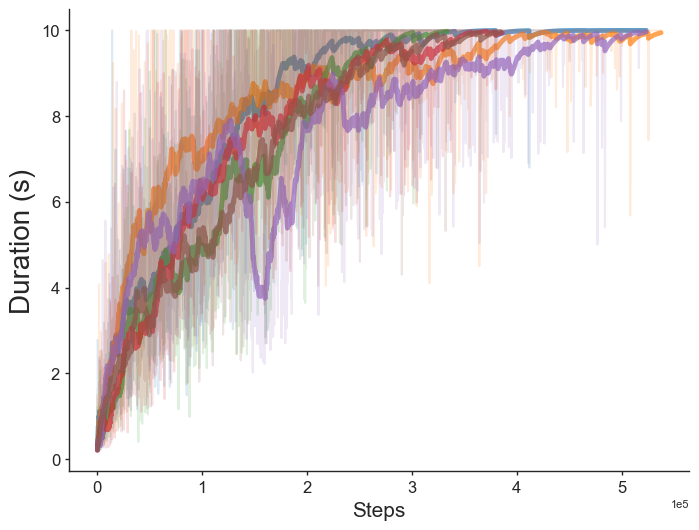

In [49]:
save_path = "../Figures/CartpoleTrainRecord.pkl"
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)
color=[
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf'
]

fig, ax = plt.subplots(figsize = (8, 6))
for j, one_train in enumerate(All_record):
    #plt.plot()
    step = one_train['step']
    cum_step = np.cumsum(step)
    smoothed = []
    t_lp = 10#step[0]
    for i, t in enumerate(step):
        t_lp = 0.95*t_lp + 0.05*t
        smoothed.append(t_lp)
    smoothed = np.array(smoothed)*action_step
    ax.plot(cum_step, step*action_step, alpha = 0.15, color=color[j])
    ax.plot(cum_step, smoothed, color=color[j], linewidth=3.5, alpha=0.7)
ax.set_xlabel("Steps", fontsize=15)
#ax.set_xticks([1e4, 2e4], [])
ax.set_ylabel("Duration (s)", fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.savefig('../Figures/CartpoleDuration.png')
plt.show()

# Adaptation and visulize

In [45]:
def episode_interpolate_adapt(env, actor, critic, critic_target, 
                              optimizer_actor, optimizer_critic,
                              adapt=False, visualize=False,):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    lamd, gamma = 0.9, 0.99
    rwd_scale = 0.2

    baseline = 0

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    if visualize:
        plt.figure(figsize=(5,4))
    frames = []

    with torch.no_grad():
        t = 0
        while not terminated and t<1000:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                if adapt:
                    value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            total_reward += reward
            reward *= rwd_scale
            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]
            
            frame = env.render()
            frames.append(frame)
            if visualize:
                plt.imshow(frame)
                plt.axis("off")
                display(plt.gcf())
                clear_output(wait=True)
            
            if adapt:
                for k in range(1, interpolate):
                    value_next,_ = critic_target.step(observations[k])
    
                delta = reward + gamma*value_next - value
                delta = torch.clamp(delta, -0.4, 0.4)

                # baseline = 0.9 * baseline + 0.1 * delta
                # delta = delta - baseline
                print(action, delta.item(), baseline)

                actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
                critic.prop(1.)
                actor.backwardsRL(delta.item(), lamd)
                critic.backwardsRL(delta.item(), lamd)

            observation = observation_next
            t+=1
            if adapt and t%50==0:
                print(actor.layers[-2].W_in.grad.data.norm(2))
                torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.)
                torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)
                #soft_update(critic_target, critic, tau = 0.05) 

    return total_reward, t, frames

In [11]:
num_trials = 100
wind = 7.

visualize = False
env = WindCartPoleEnv(wind=wind, render_mode="rgb_array")
env = CartPoleCustomize(env=env)  #Do we need time limit?
#env = CartPoleCustomize(env=None, display = True)
actor_state_dict = torch.load(general_config['save_path']+"actor493.ckp", weights_only=False)
critic_state_dict = torch.load(general_config['save_path']+"critic493.ckp", weights_only=False)

actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)

In [29]:
#Without online adpation
noAdapt_reward, noAdapt_time = [], []
actor.load_state_dict(actor_state_dict)
critic.load_state_dict(critic_state_dict)
critic_target.load_state_dict(critic_state_dict)

for i in range(num_trials):
    total_reward, t, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     None, None, adapt=False, visualize=visualize,)
    noAdapt_reward.append(total_reward)
    noAdapt_time.append(t)
    if total_reward < 0:
        imageio.mimsave("../Figures/cartpole_noAdapt%.1f.gif"%total_reward, frames, fps=30)

noAdapt_reward = np.array(noAdapt_reward)
noAdapt_time = np.array(noAdapt_time)
print("Average Reward without adaptation: ", noAdapt_reward.mean())

Average Reward without adaptation:  314.646


In [48]:
#With online adpation
Adapt_reward, Adapt_time = [], []
for i in range(num_trials):
    actor.load_state_dict(actor_state_dict)
    critic.load_state_dict(critic_state_dict)
    critic_target.load_state_dict(critic_state_dict)
    # optimizer_actor = torch.optim.RMSprop(
    #     actor.parameters(),
    #     lr=1e-4, alpha=0.6
    # )
    # optimizer_critic = torch.optim.RMSprop(
    #     critic.parameters(),
    #     lr=1e-3, alpha=0.6
    # )

    optimizer_actor = torch.optim.SGD(
        actor.parameters(),
        lr=1e-3,
    )
    optimizer_critic = torch.optim.SGD(
        critic.parameters(),
        lr=1e-4,
    )
    
    total_reward, t, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=True, visualize=visualize,)
    Adapt_reward.append(total_reward)
    Adapt_time.append(t)
    if total_reward > 750:
        imageio.mimsave("../Figures/cartpole_Adapt%.1f.gif"%total_reward, frames, fps=30)
Adapt_reward = np.array(Adapt_reward)
Adapt_time = np.array(Adapt_time)
print("Average Reward with adaptation: ", Adapt_reward.mean())

1 -0.14433956146240234 0
0 -0.15181541442871094 0
0 -0.12741565704345703 0
0 -0.10686206817626953 0
0 -0.09435558319091797 0
0 -0.08481884002685547 0
0 -0.07322978973388672 0
0 -0.05720043182373047 0
0 -0.03655719757080078 0
0 -0.011774063110351562 0
0 0.016710281372070312 0
0 0.047870635986328125 0
0 0.07944869995117188 0
0 0.10819816589355469 0
1 -0.04623222351074219 0
0 -0.059662818908691406 0
0 -0.04924488067626953 0
0 -0.0303497314453125 0
0 -0.006958961486816406 0
0 0.020425796508789062 0
0 0.050506591796875 0
0 0.08093452453613281 0
0 0.1089944839477539 0
0 0.13163280487060547 0
0 0.14523792266845703 0
0 0.1462574005126953 0
1 -0.001354217529296875 0
0 0.024321556091308594 0
0 0.05268096923828125 0
0 0.07814502716064453 0
0 0.10074615478515625 0
1 -0.040045738220214844 0
0 -0.02504730224609375 0
0 0.0029745101928710938 0
0 0.03339385986328125 0
0 0.06687068939208984 0
0 0.10228919982910156 0
0 0.13538169860839844 0
0 0.1592874526977539 0
0 0.1658039093017578 0
0 0.14898490905761

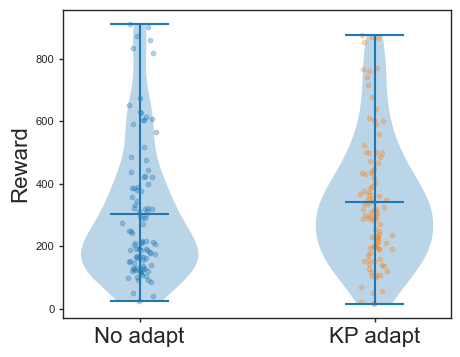

In [16]:
#TODO plot the bar with many runs
fig, ax = plt.subplots(figsize = (5, 4))

data = [noAdapt_reward, Adapt_reward]
#data = [noAdapt_time, Adapt_time]
ax.violinplot(data, positions=[0,1], showmeans=True)
ax.set_xticks([0,1], ['No adapt', 'KP adapt'], fontsize=16)
ax.set_ylabel("Reward", fontsize=16)

for i, d in enumerate(data):
    x = np.random.normal(i, 0.03, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.3, s=10)

#plt.savefig('../Figures/CartpoleAdpation.png')
plt.show()

In [17]:
(noAdapt_time > 500).sum()/num_trials

np.float64(0.17)

In [18]:
(Adapt_time > 500).sum()/num_trials

np.float64(0.22)

In [28]:
class SimpleCartPoleController:
    def __init__(self):
        self.k_x = 0.5
        self.k_x_dot = 0.1
        self.k_theta = 5.0
        self.k_theta_dot = 0.5

        self.bias = 0.0
        self.alpha = 0.01

    def act(self, obs):
        x, x_dot, theta, theta_dot = obs

        self.bias += self.alpha * x

        u = -(self.k_x * x +
              self.k_x_dot * x_dot +
              self.k_theta * theta +
              self.k_theta_dot * theta_dot +
              self.bias)

        return 1 if u > 0 else 0, abs(u)  # return confidence

def episode_adapt_controller(env, actor, controller, optimizer_actor, adapt=False):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()

    terminated, truncated = False, False
    total_reward=0

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    frames = []

    with torch.no_grad():
        t = 0
        while not terminated and t<1000:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            if adapt:
                # --- controller signal ---
                observation_full = env.obs
                ctrl_action, ctrl_conf = controller.act(observation_full)
                # confidence scaling (optional but important)
                conf = min(1.0, ctrl_conf / 10.0)
                # supervised direction
                target = F.one_hot(torch.tensor(ctrl_action), num_classes=n_actions).float()
                # policy gradient-style update toward controller
                signal = (target - p) * conf
                
                actor.prop(signal)
                actor.backwards()
                if t % 100 == 0:
                    #torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.)
                    optimizer_actor.step()
                    optimizer_actor.zero_grad(set_to_none=False)

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            total_reward += reward
            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]
            
            frame = env.render()
            frames.append(frame)

            observation = observation_next
            t += 1

    return total_reward, t, frames

In [20]:
class PD:
    def __init__(self, kp, kd, goal):
        self.kp = kp
        self.kd = kd
        self.goal = goal
        self.last_error = 0

    def observe(self, x):
        error = self.goal - x
        d_error = error - self.last_error
        self.last_error = error
        return self.kp * error + self.kd * d_error

class PD2Controller:
    def __init__(self):
        self.cart = PD(kp=1, kd=100, goal=0)
        self.pole = PD(kp=5, kd=100, goal=0)

    def act(self, obs):
        cart_position, _, pole_angle, _ = obs
        u_cart = self.cart.observe(cart_position)
        u_pole = self.pole.observe(pole_angle)
        action = 1 if u_pole + u_cart < 0 else 0
        return action, 1

class TwoLoopPIDController:
    def __init__(self):
        # outer loop (position → angle)
        self.kp_x = 0.5
        self.kd_x = 0.2
        self.ki_x = 0.02

        # inner loop (angle → force)
        self.kp_theta = 8.0
        self.kd_theta = 0.8

        self.x_int = 0.0

    def act(self, obs):
        x, x_dot, theta, theta_dot = obs

        # integral (compensates wind)
        self.x_int += x

        # outer loop: desired angle
        theta_target = (
            self.kp_x * x +
            self.kd_x * x_dot +
            self.ki_x * self.x_int
        )

        # inner loop: track angle
        u = self.kp_theta * (theta - theta_target) + self.kd_theta * theta_dot

        action = 1 if u > 0 else 0

        confidence = abs(u)
        return action, confidence

In [31]:
Adapt_reward, Adapt_time = [], []
for i in range(num_trials):
    actor.load_state_dict(actor_state_dict)
    optimizer_actor = torch.optim.RMSprop(
        actor.parameters(),
        lr=1e-4, alpha=0.8
    )
    # optimizer_actor = torch.optim.SGD(
    #     actor.parameters(),
    #     lr=1e-4,
    # )
    #controller = PD2Controller()
    controller = TwoLoopPIDController()
    total_reward, t, frames = episode_adapt_controller(env, actor, controller, optimizer_actor, adapt=True)
    Adapt_reward.append(total_reward)
    Adapt_time.append(t)
    if total_reward > 750:
        imageio.mimsave("../Figures/cartpole_Adapt%.1f.gif"%total_reward, frames, fps=30)
Adapt_reward = np.array(Adapt_reward)
Adapt_time = np.array(Adapt_time)
print("Average Reward with adaptation: ", Adapt_reward.mean())

Average Reward with adaptation:  304.13757


In [52]:
#TODO multi-episode learn, faster than BPTT?